In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('life_expectancy.csv')
df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


In [2]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   str    
 1   Region                       2864 non-null   str    
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita               

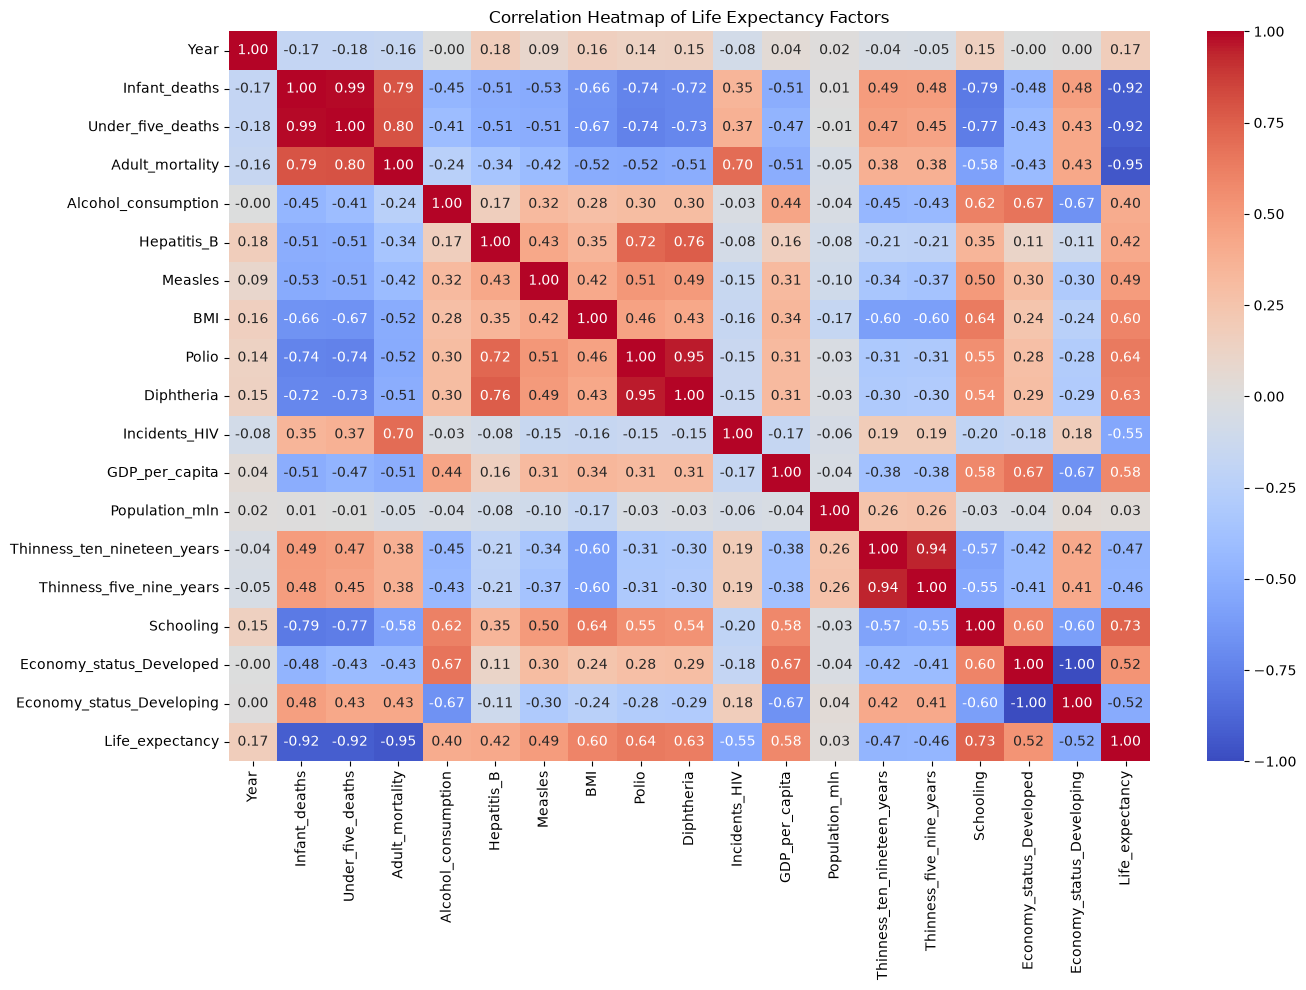

In [3]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Life Expectancy Factors')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

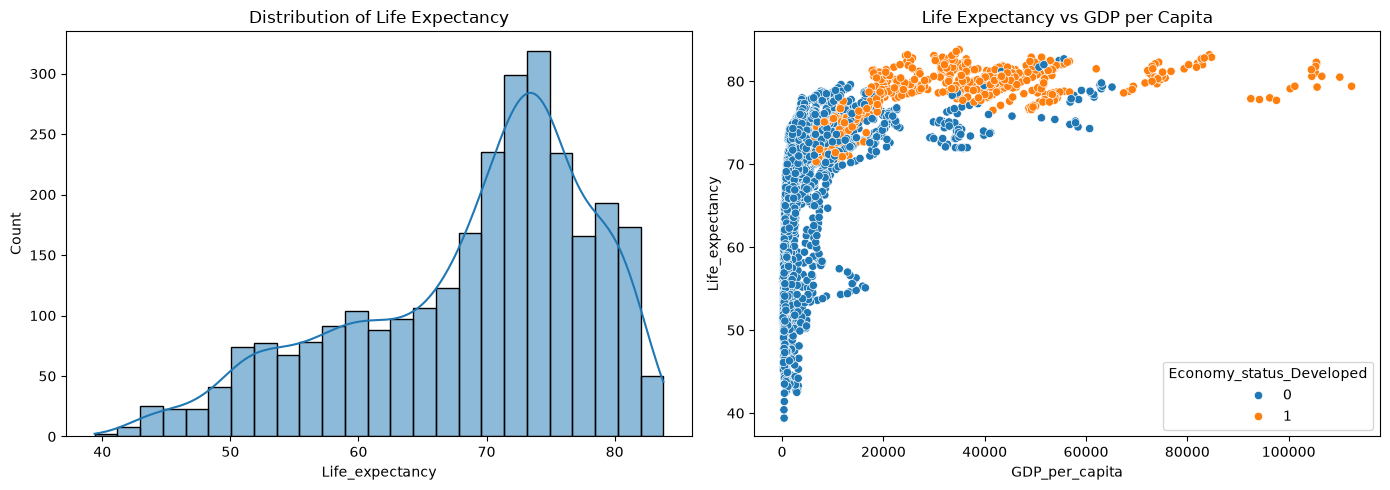

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Life_expectancy'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Life Expectancy')

sns.scatterplot(data=df, x='GDP_per_capita', y='Life_expectancy', hue='Economy_status_Developed', ax=axes[1])
axes[1].set_title('Life Expectancy vs GDP per Capita')
plt.tight_layout()
plt.savefig('distribution_plots.png')
plt.show()

In [5]:
df_model = df.drop(columns=['Country', 'Economy_status_Developing'])

# Encode Region as numeric
df_model = pd.get_dummies(df_model, columns=['Region'], drop_first=True)

df_model.head()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,...,Economy_status_Developed,Life_expectancy,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America
0,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,97,...,0,76.5,False,False,False,True,False,False,False,False
1,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,97,...,1,82.8,False,False,True,False,False,False,False,False
2,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,64,...,0,65.4,True,False,False,False,False,False,False,False
3,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,93,...,0,67.0,False,False,False,False,False,False,False,True
4,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,94,...,1,81.7,False,False,False,True,False,False,False,False


In [6]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Life_expectancy'])
y = df_model['Life_expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(2291, 25) (573, 25)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_mse = mean_squared_error(y_test, lr_pred)
print(f"Linear Regression MSE: {lr_mse:.4f}, R2: {r2_score(y_test, lr_pred):.4f}")

Linear Regression MSE: 1.4738, R2: 0.9822


In [9]:
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train_scaled, y_train)
sgd_pred = sgd.predict(X_test_scaled)
sgd_mse = mean_squared_error(y_test, sgd_pred)
print(f"SGD Regression MSE: {sgd_mse:.4f}, R2: {r2_score(y_test, sgd_pred):.4f}")

SGD Regression MSE: 1.4943, R2: 0.9820


In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_mse = mean_squared_error(y_test, rf_pred)
print(f"Random Forest MSE: {rf_mse:.4f}, R2: {r2_score(y_test, rf_pred):.4f}")

Random Forest MSE: 0.2259, R2: 0.9973


In [11]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
dt_mse = mean_squared_error(y_test, dt_pred)
print(f"Decision Tree MSE: {dt_mse:.4f}, R2: {r2_score(y_test, dt_pred):.4f}")

Decision Tree MSE: 0.5673, R2: 0.9932


In [12]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'SGD Regression', 'Random Forest', 'Decision Tree'],
    'MSE': [lr_mse, sgd_mse, rf_mse, dt_mse],
    'R2': [r2_score(y_test, lr_pred), r2_score(y_test, sgd_pred), r2_score(y_test, rf_pred), r2_score(y_test, dt_pred)]
})
results.sort_values('MSE')

,Model,MSE,R2
2,Random Forest,0.225911,0.997278
3,Decision Tree,0.567295,0.993164
0,Linear Regression,1.473849,0.982241
1,SGD Regression,1.494253,0.981995


In [13]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\FADHILI\linear_regression_model\summative\linear_regression
['.ipynb_checkpoints', 'before_after_fit.png', 'best_model.pkl', 'correlation_heatmap.png', 'distribution_plots.png', 'feature_columns.pkl', 'life_expectancy.csv', 'loss_curve.png', 'multivariate.ipynb', 'scaler.pkl']


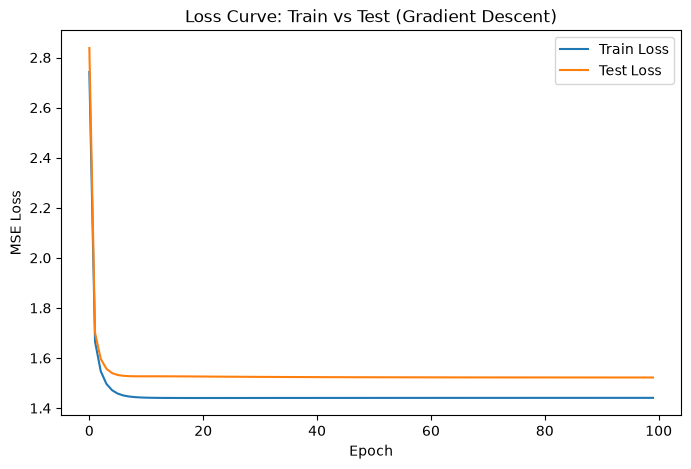

In [14]:
from sklearn.linear_model import SGDRegressor

train_losses = []
test_losses = []
sgd_partial = SGDRegressor(max_iter=1, tol=None, warm_start=True, random_state=42)

for epoch in range(100):
    sgd_partial.fit(X_train_scaled, y_train)
    train_pred = sgd_partial.predict(X_train_scaled)
    test_pred = sgd_partial.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve: Train vs Test (Gradient Descent)')
plt.legend()
plt.savefig('loss_curve.png')
plt.show()

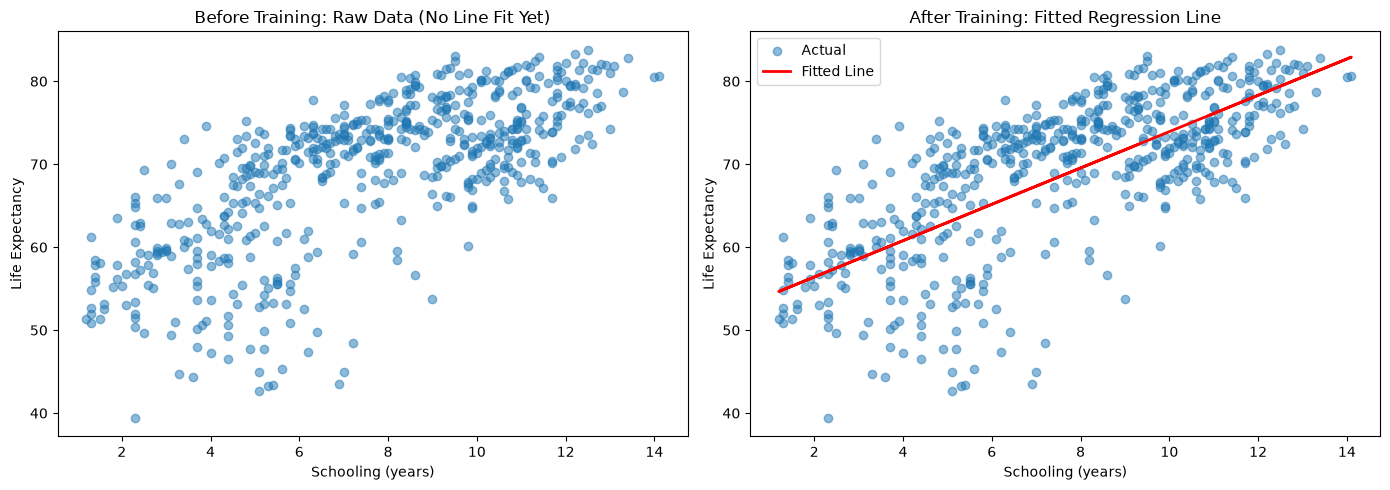

In [15]:
from sklearn.linear_model import LinearRegression as LR_simple

X_school = df_model[['Schooling']]
y_life = df_model['Life_expectancy']
X_school_train, X_school_test, y_school_train, y_school_test = train_test_split(X_school, y_life, test_size=0.2, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before training: random/unfit line
axes[0].scatter(X_school_test, y_school_test, alpha=0.5)
axes[0].set_title('Before Training: Raw Data (No Line Fit Yet)')
axes[0].set_xlabel('Schooling (years)')
axes[0].set_ylabel('Life Expectancy')

# After training: fitted regression line
simple_lr = LR_simple()
simple_lr.fit(X_school_train, y_school_train)
axes[1].scatter(X_school_test, y_school_test, alpha=0.5, label='Actual')
axes[1].plot(X_school_test, simple_lr.predict(X_school_test), color='red', linewidth=2, label='Fitted Line')
axes[1].set_title('After Training: Fitted Regression Line')
axes[1].set_xlabel('Schooling (years)')
axes[1].set_ylabel('Life Expectancy')
axes[1].legend()

plt.tight_layout()
plt.savefig('before_after_fit.png')
plt.show()

In [16]:
import joblib

joblib.dump(rf, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')
print("Model, scaler, and feature columns saved.")

Model, scaler, and feature columns saved.


In [17]:
# Load back to simulate how the API will use it
loaded_model = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

sample_row = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample_row)
prediction = loaded_model.predict(sample_scaled)
print(f"Sample input:\n{sample_row}")
print(f"Predicted Life Expectancy: {prediction[0]:.2f}")
print(f"Actual Life Expectancy: {y_test.iloc[0]}")

Sample input:
      Year  Infant_deaths  Under_five_deaths  Adult_mortality  \
1590  2006           14.3               16.7          176.668   

      Alcohol_consumption  Hepatitis_B  Measles   BMI  Polio  Diphtheria  ...  \
1590                 9.82           96       83  27.2     94          95  ...   

      Schooling  Economy_status_Developed  Region_Asia  \
1590       10.9                         0        False   

      Region_Central America and Caribbean  Region_European Union  \
1590                                  True                  False   

      Region_Middle East  Region_North America  Region_Oceania  \
1590               False                 False           False   

      Region_Rest of Europe  Region_South America  
1590                  False                 False  

[1 rows x 25 columns]
Predicted Life Expectancy: 72.19
Actual Life Expectancy: 72.0
